# EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("../data/processed/datos_limpios.csv")
OUTPUT_DIR = Path("../outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
blue = "steelblue"

TARGET = "Churn"

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,160
1,50002,1,9,Mobile Phone,1,8,UPI,Male,3,4,Mobile Phone,3,Single,7,1,15,0,1,0,121
2,50003,1,9,Mobile Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,1,14,0,1,3,120
3,50004,1,0,Mobile Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134
4,50005,1,0,Mobile Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,0,11,1,1,3,130


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5074 entries, 0 to 5073
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   CustomerID                   5074 non-null   int64
 1   Churn                        5074 non-null   int64
 2   Tenure                       5074 non-null   int64
 3   PreferredLoginDevice         5074 non-null   str  
 4   CityTier                     5074 non-null   int64
 5   WarehouseToHome              5074 non-null   int64
 6   PreferredPaymentMode         5074 non-null   str  
 7   Gender                       5074 non-null   str  
 8   HourSpendOnApp               5074 non-null   int64
 9   NumberOfDeviceRegistered     5074 non-null   int64
 10  PreferedOrderCat             5074 non-null   str  
 11  SatisfactionScore            5074 non-null   int64
 12  MaritalStatus                5074 non-null   str  
 13  NumberOfAddress              5074 non-null   int64
 14  Com

In [4]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5074.000000,5074.000000,5074.000000,5074.000000,5074.000000,5074.00000,5074.000000,5074.000000,5074.000000,5074.000000,5074.000000,5074.000000,5074.000000,5074.000000,5074.00000
mean,52718.681908,0.165747,10.158652,1.658455,15.435357,2.93240,3.686244,3.027986,4.194521,0.282617,15.678557,1.772566,3.041190,4.492117,177.63579
std,1613.253149,0.371890,8.396085,0.919284,8.425568,0.70729,1.029670,1.384493,2.578819,0.450316,3.592399,1.912925,2.931923,3.575884,49.37252
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.00000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.00000
25%,51269.250000,0.000000,3.000000,1.000000,9.000000,2.00000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.00000
50%,52816.500000,0.000000,9.000000,1.000000,13.000000,3.00000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,164.00000
75%,54084.750000,0.000000,15.000000,3.000000,19.000000,3.00000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,198.00000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.00000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.00000


In [5]:
target_summary = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET)
    .to_frame("clientes")
    .assign(porcentaje=lambda x: (x["clientes"] / len(df) * 100).round(2))
)
target_summary

,clientes,porcentaje
Churn,,
0,4233,83.43
1,841,16.57


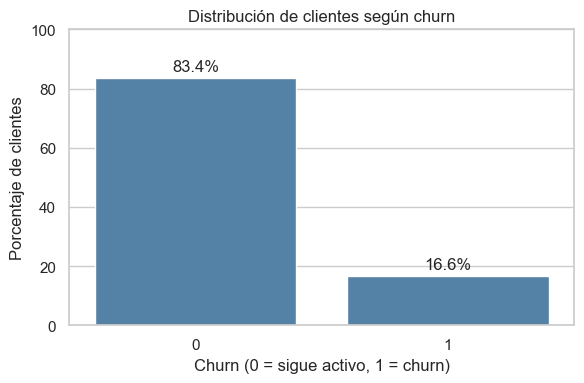

In [6]:

churn_pct = (
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

churn_pct.columns = [TARGET, "Porcentaje"]
churn_pct = churn_pct.sort_values(TARGET)

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=churn_pct,
    x=TARGET,
    y="Porcentaje",
    ax=ax,
    color=blue
)

ax.set_title("Distribución de clientes según churn")
ax.set_xlabel("Churn (0 = sigue activo, 1 = churn)")
ax.set_ylabel("Porcentaje de clientes")

# Etiquetas arriba de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" for v in container.datavalues],
        padding=3
    )

ax.set_ylim(0, 100)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "0_distribucion_churn.png", dpi=150)
plt.show()

La tasa observada de churn es 16,6%, aproximadamente 1 de cada 6 clientes. La clase positiva es minoritaria, por lo que el modelado debe usar split estratificado y métricas orientadas a detectar churners; accuracy por sí sola puede resultar engañosa.

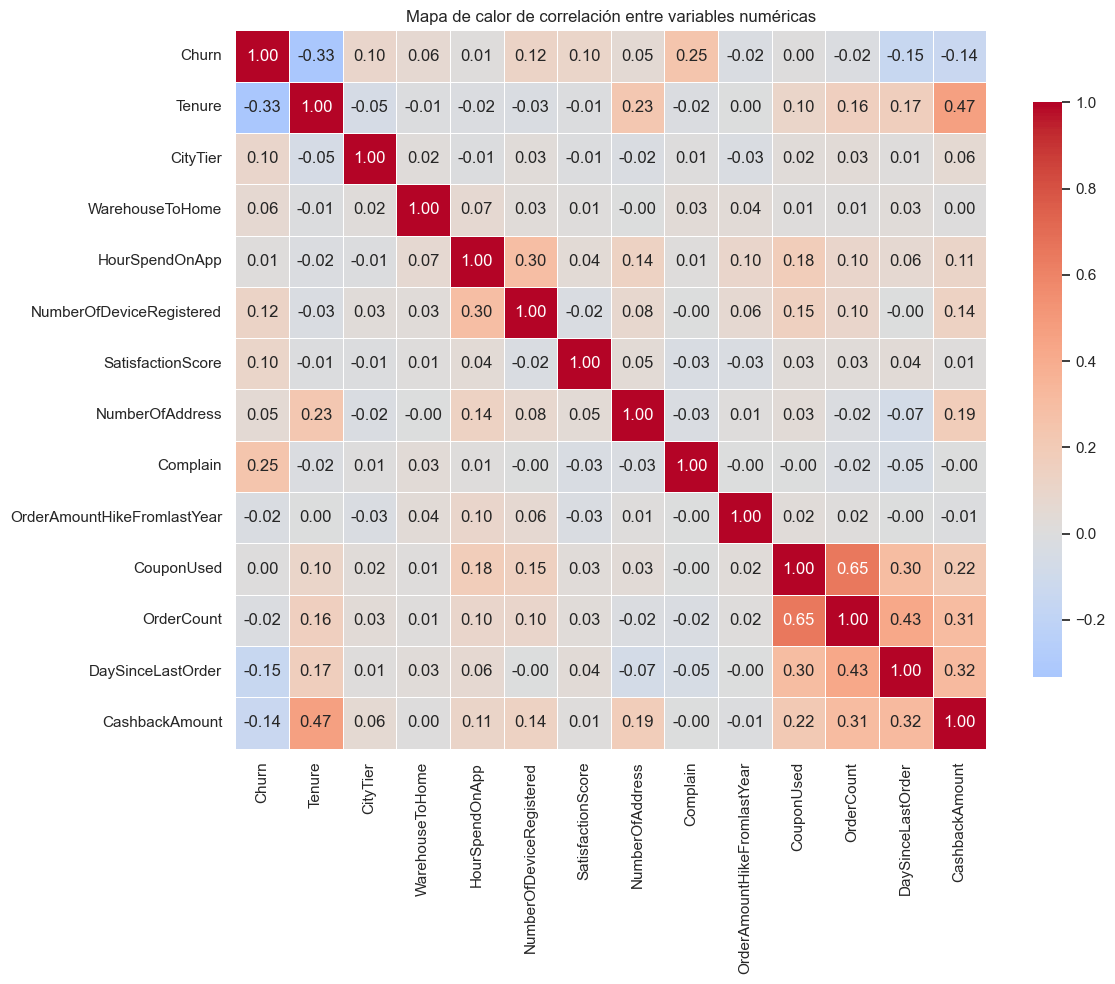

In [7]:
df_corr = df.drop(columns=["CustomerID"], errors="ignore")

numeric_cols = df_corr.select_dtypes(include="number").columns
corr_matrix = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Mapa de calor de correlación entre variables numéricas")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Insight del mapa de correlación

El mapa muestra que **ninguna variable numérica tiene una correlación muy fuerte con `Churn`**, por lo que el abandono no parece depender de un solo factor.

Los insights más importantes son:

- **Tenure** tiene correlación negativa con `Churn` (**-0.33**): cuanto más antiguo es el cliente, menos probable es que abandone.
- **Complain** tiene correlación positiva con `Churn` (**0.25**): los clientes que reclaman tienden a irse más.
- **CouponUsed** y **OrderCount** tienen una correlación positiva relativamente alta (**0.65**), aunque el VIF aproximado de **1.72** no indica multicolinealidad severa.
- **Tenure** y **CashbackAmount** también tienen una relación moderada (**0.47**).

En conclusión, `Tenure` y `Complain` parecen ser las variables más relevantes para explicar churn, pero conviene usar un modelo que combine varias variables porque no hay una única variable que lo explique sola.

Correlación entre CouponUsed y OrderCount: 0.647
R² aproximado: 0.418
VIF aproximado: 1.72
Número de observaciones usadas: 5074


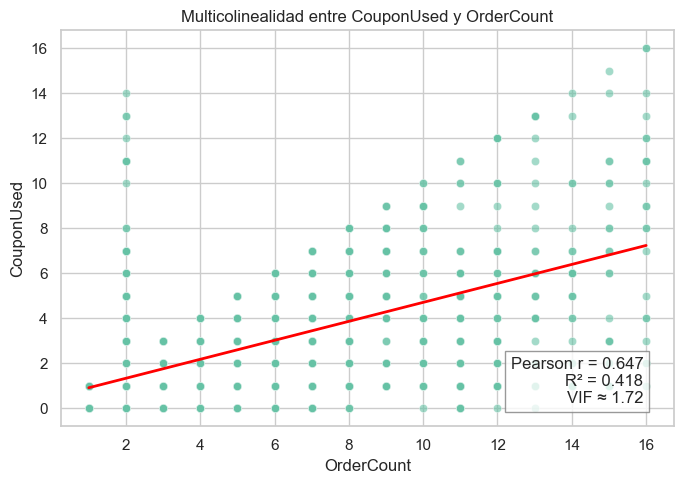

In [8]:
df_mc = df[["CouponUsed", "OrderCount"]].dropna()

corr = df_mc["CouponUsed"].corr(df_mc["OrderCount"])
r2 = corr**2
vif = 1 / (1 - r2)

print(f"Correlación entre CouponUsed y OrderCount: {corr:.3f}")
print(f"R² aproximado: {r2:.3f}")
print(f"VIF aproximado: {vif:.2f}")
print(f"Número de observaciones usadas: {len(df_mc)}")

fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=df_mc,
    x="OrderCount",
    y="CouponUsed",
    alpha=0.6,
    ax=ax
)

slope, intercept = np.polyfit(df_mc["OrderCount"], df_mc["CouponUsed"], 1)
x_line = np.linspace(df_mc["OrderCount"].min(), df_mc["OrderCount"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", lw=2)

ax.set_title("Multicolinealidad entre CouponUsed y OrderCount")
ax.set_xlabel("OrderCount")
ax.set_ylabel("CouponUsed")
ax.text(
    0.95,
    0.05,
    f"Pearson r = {corr:.3f}\nR² = {r2:.3f}\nVIF ≈ {vif:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "multicolinealidad_couponused_ordercount.png", dpi=150, bbox_inches="tight")
plt.show()

Al tener un VIF menor a 10 podemos decir que no presentan multicolinealidad severa. De esta forma, dejamos ambas features en el modelo.

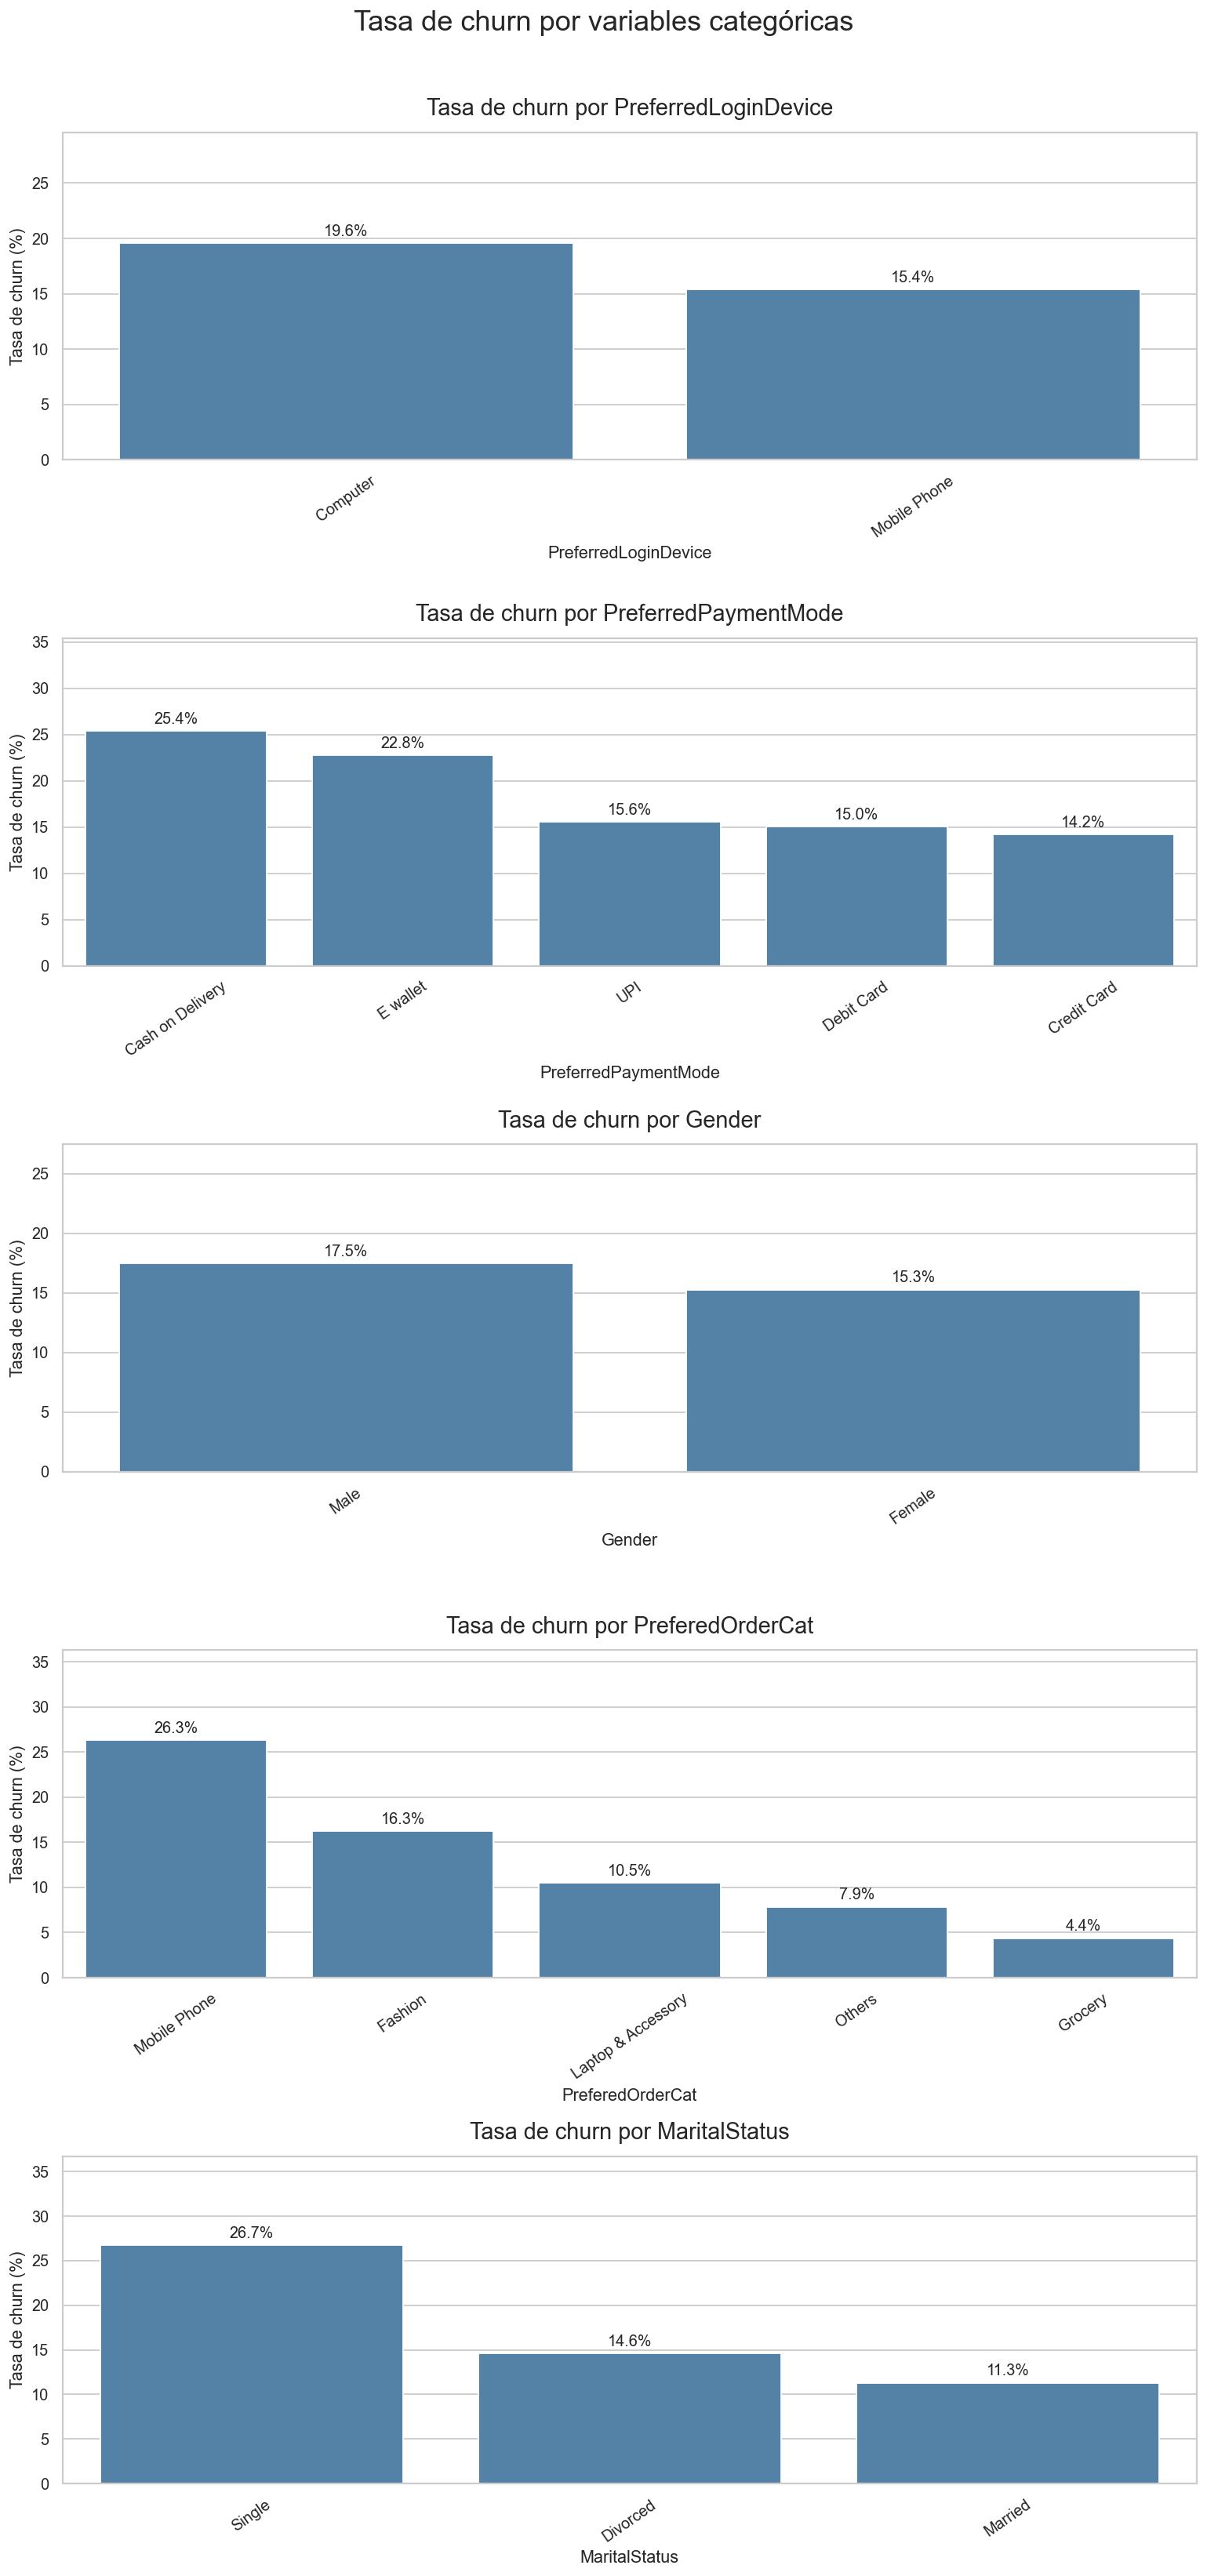

In [9]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 130

# Seleccionar variables categóricas
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Opcional: sacar columnas tipo ID
categorical_cols = [
    col for col in categorical_cols
    if "id" not in col.lower()
]

# Una sola columna
n_cols = 1
n_rows = len(categorical_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 5 * n_rows)
)

# Si hay una sola variable, axes no viene como lista
if n_rows == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    
    cat_churn = (
        df.groupby(col)[TARGET]
        .agg(clientes="size", churn_rate="mean")
        .reset_index()
    )
    
    cat_churn["churn_rate_pct"] = cat_churn["churn_rate"] * 100
    cat_churn = cat_churn.sort_values("churn_rate_pct", ascending=False)
    
    sns.barplot(
        data=cat_churn,
        x=col,
        y="churn_rate_pct",
        color=blue,
        ax=ax
    )
    
    ax.set_title(f"Tasa de churn por {col}", fontsize=16, pad=12)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Tasa de churn (%)", fontsize=12)
    ax.tick_params(axis="x", rotation=35, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    
    max_y = cat_churn["churn_rate_pct"].max()
    ax.set_ylim(0, min(100, max_y + 10))
    
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            fontsize=11,
            padding=3
        )

fig.suptitle(
    "Tasa de churn por variables categóricas",
    fontsize=20,
    y=1.01
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "relacion_categoricas_churn.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Conclusión del análisis categórico

Las variables categóricas muestran diferencias claras en la tasa de churn según el perfil del cliente.

Los segmentos con mayor churn son:

- **Clientes solteros**: 26.7%
- **Categoría Mobile Phone**: 26.3% luego de consolidar `Mobile` y `Mobile Phone`
- **Método de pago Cash on Delivery**: 25.4%, la mayor tasa entre los medios de pago luego de consolidar `COD` y `Cash on Delivery`
- **Login desde Computer**: 19.6%, por encima de Mobile Phone (15.4%)

En cambio, los segmentos con menor churn son:

- **Clientes casados**: 11.3%
- **Categoría Grocery**: 4.4%
- **Pago con Credit Card**: 14.2%, menor que Cash on Delivery luego de consolidar `CC` y `Credit Card`
- **Login desde Mobile Phone**: 15.4%, menor que Computer

En general, las variables categóricas muestran segmentos con riesgos diferentes. Los contrastes más marcados aparecen en estado civil, categoría de compra y medio de pago; el dispositivo de login presenta una diferencia menor y en sentido contrario al supuesto inicial.

# EDA guiado por hipotesis

Este notebook valida las hipotesis escritas por el equipo en `reports/01_hipotesis.md`.

Criterio de trabajo:
- No se generan hipotesis nuevas automaticamente.
- Se usan graficos y tests para contrastar las hipotesis existentes.
- Los resultados son un borrador tecnico: despues deben revisarse manualmente antes de convertirse en conclusiones finales.


## Funciones auxiliares para tests

- Variables numericas vs target binario: Mann-Whitney U, porque no asumimos normalidad.
- Variables categoricas u ordinales vs target binario: chi-cuadrado de independencia.
- Reportamos p-valor y tamaño de efecto para no depender solo de significancia estadistica.


In [10]:
def format_pvalue(p_value):
    return "< 0.001" if p_value < 0.001 else f"{p_value:.4f}"

def mann_whitney_test(data, feature, target=TARGET):
    subset = data[[feature, target]].dropna()
    churn_values = subset.loc[subset[target] == 1, feature]
    no_churn_values = subset.loc[subset[target] == 0, feature]
    statistic, p_value = stats.mannwhitneyu(churn_values, no_churn_values, alternative="two-sided")
    rank_biserial = (2 * statistic) / (len(churn_values) * len(no_churn_values)) - 1
    return {
        "feature": feature,
        "test": "Mann-Whitney U",
        "n_used": len(subset),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": rank_biserial,
        "mean_churn": churn_values.mean(),
        "mean_no_churn": no_churn_values.mean(),
        "median_churn": churn_values.median(),
        "median_no_churn": no_churn_values.median(),
    }


def cramers_v(table):
    chi2, _, _, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan


def chi_square_test(data, feature, target=TARGET):
    subset = data[[feature, target]].dropna()
    table = pd.crosstab(subset[feature], subset[target])
    statistic, p_value, dof, expected = stats.chi2_contingency(table)
    return {
        "feature": feature,
        "test": "Chi-square",
        "n_used": len(subset),
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": cramers_v(table),
        "dof": dof,
    }

## H1 - Tenure

**Hipotesis:** Los clientes con menor `Tenure` tienden a churnear mas.

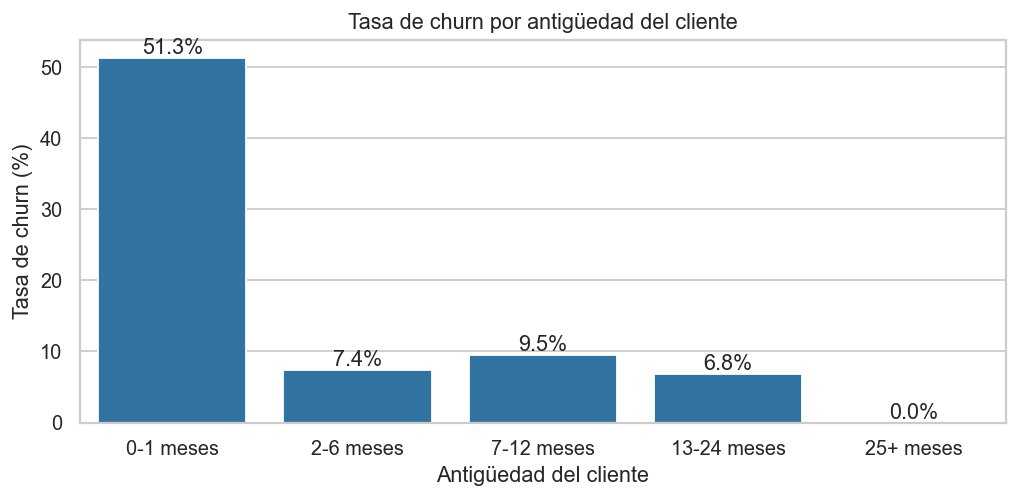

,tenure_segment,clientes,churn_rate,churn_rate_pct
0,0-1 meses,1076,0.513011,51.301115
1,2-6 meses,868,0.073733,7.373272
2,7-12 meses,1415,0.095406,9.540636
3,13-24 meses,1322,0.068079,6.807867
4,25+ meses,393,0.000000,0.000000


In [11]:
df_tenure = df[["Tenure", "Churn"]].dropna().copy()

df_tenure["tenure_segment"] = pd.cut(
    df_tenure["Tenure"],
    bins=[-1, 1, 6, 12, 24, df_tenure["Tenure"].max()],
    labels=["0-1 meses", "2-6 meses", "7-12 meses", "13-24 meses", "25+ meses"]
)

tenure_churn = (
    df_tenure
    .groupby("tenure_segment", observed=True)
    .agg(
        clientes=("Churn", "size"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

tenure_churn["churn_rate_pct"] = tenure_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=tenure_churn,
    x="tenure_segment",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn por antigüedad del cliente")
ax.set_xlabel("Antigüedad del cliente")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H1_tenure_churn_rate_por_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

tenure_churn

In [12]:
h1_result = mann_whitney_test(df, "Tenure")
h1_result

{'feature': 'Tenure',
 'test': 'Mann-Whitney U',
 'n_used': 5074,
 'statistic': np.float64(740756.0),
 'p_value': np.float64(1.2348656427925575e-158),
 'effect_size': np.float64(-0.5838394495657667),
 'mean_churn': np.float64(3.9131985731272296),
 'mean_no_churn': np.float64(11.399480274037325),
 'median_churn': np.float64(1.0),
 'median_no_churn': np.float64(10.0)}

Los clientes que churnearon tienen una antigüedad mediana de 1 mes, mientras que los clientes activos tienen una mediana de 10 meses. Esto apoya la hipótesis de que los clientes nuevos son más propensos a abandonar, por lo que conviene reforzar acciones de onboarding y retención temprana.

## H2 - Complain

**Hipotesis:** Los clientes con reclamos tienden a churnear mas.

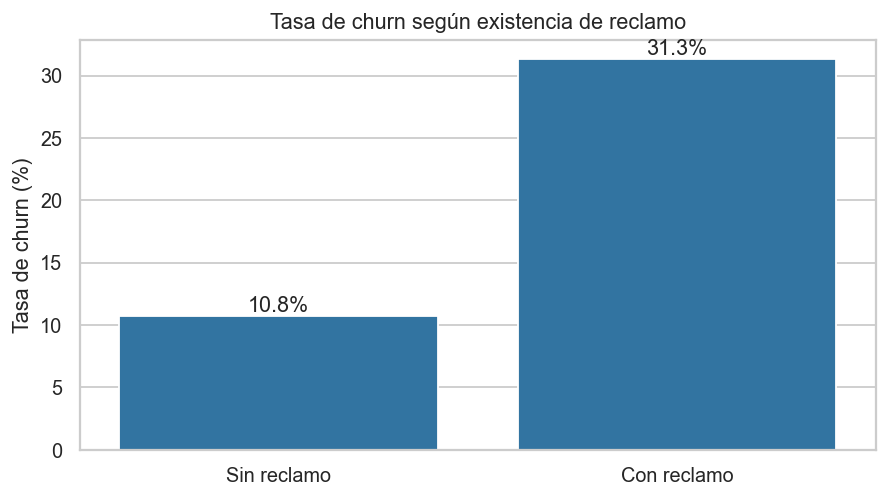

,Complain_label,clientes,churn_rate_pct
0,Sin reclamo,3640,10.769231
1,Con reclamo,1434,31.311018


In [13]:
complain_churn = (
    df.groupby("Complain")["Churn"]
    .agg(clientes="size", churn_rate="mean")
    .reset_index()
)

complain_churn["churn_rate_pct"] = complain_churn["churn_rate"] * 100
complain_churn["Complain_label"] = complain_churn["Complain"].map({
    0: "Sin reclamo",
    1: "Con reclamo"
})

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=complain_churn,
    x="Complain_label",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según existencia de reclamo")
ax.set_xlabel("")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H2_complain_churn_rate.png", dpi=150, bbox_inches="tight")
plt.show()

complain_churn[["Complain_label", "clientes", "churn_rate_pct"]]

In [14]:
h2_result = chi_square_test(df, "Complain")
h2_result

{'feature': 'Complain',
 'test': 'Chi-square',
 'n_used': 5074,
 'statistic': np.float64(312.4464504791373),
 'p_value': np.float64(6.40160048152556e-70),
 'effect_size': np.float64(0.24814902102093703),
 'dof': 1}

Los clientes con reclamos presentan una tasa de churn de 31,3%, frente a 10,8% en clientes sin reclamos. Esto apoya la hipótesis de que una mala experiencia registrada mediante reclamos está asociada con mayor abandono.

## H3 - SatisfactionScore

**Hipotesis:** Los clientes con menor `SatisfactionScore` tienden a churnear mas.

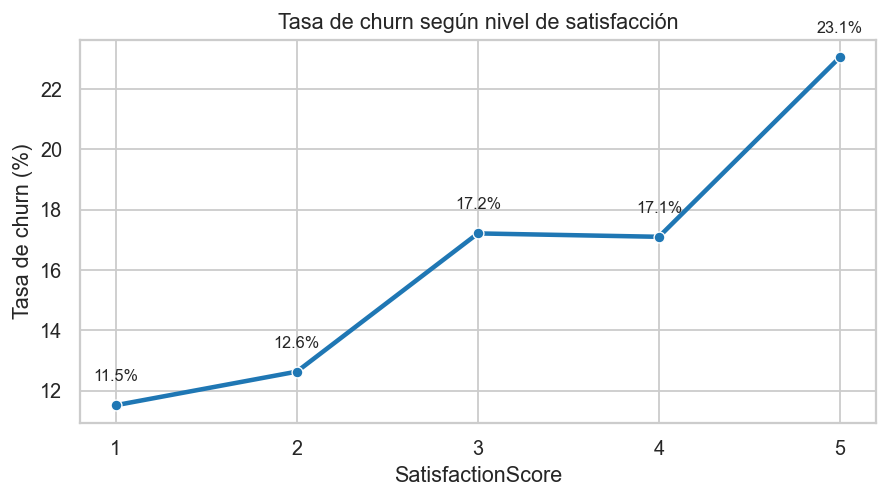

,SatisfactionScore,clientes,churn_rate_pct
0,1,1077,11.513463
1,2,586,12.627986
2,3,1505,17.209302
3,4,930,17.096774
4,5,976,23.053279


In [15]:
satisfaction_churn = (
    df.groupby("SatisfactionScore")["Churn"]
    .agg(clientes="size", churn_rate="mean")
    .reset_index()
)

satisfaction_churn["churn_rate_pct"] = satisfaction_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))

sns.lineplot(
    data=satisfaction_churn,
    x="SatisfactionScore",
    y="churn_rate_pct",
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según nivel de satisfacción")
ax.set_xlabel("SatisfactionScore")
ax.set_ylabel("Tasa de churn (%)")
ax.set_xticks(sorted(df["SatisfactionScore"].unique()))

for _, row in satisfaction_churn.iterrows():
    ax.text(
        row["SatisfactionScore"],
        row["churn_rate_pct"] + 0.8,
        f"{row['churn_rate_pct']:.1f}%",
        ha="center",
        fontsize=9
    )

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H3_satisfaction_churn_rate_linea.png", dpi=150, bbox_inches="tight")
plt.show()

satisfaction_churn[["SatisfactionScore", "clientes", "churn_rate_pct"]]

In [16]:
h3_result = chi_square_test(df, "SatisfactionScore")
h3_result

{'feature': 'SatisfactionScore',
 'test': 'Chi-square',
 'n_used': 5074,
 'statistic': np.float64(56.80036507405269),
 'p_value': np.float64(1.3624088809826223e-11),
 'effect_size': np.float64(0.10580357250434058),
 'dof': 4}

Esperábamos que menor satisfacción implicara mayor churn, pero el patrón observado va en sentido contrario. Por eso, no conviene interpretar `SatisfactionScore` de manera lineal ni asumir que un score alto implica menor riesgo de abandono. Por el contrario, debemos estudiar por qué los clientes con mayor satisfacción tienen mayor churn rate lo cual es muy raro.

## H4 - OrderCount

**Hipotesis:** Los clientes con menor `OrderCount` tienden a churnear mas.

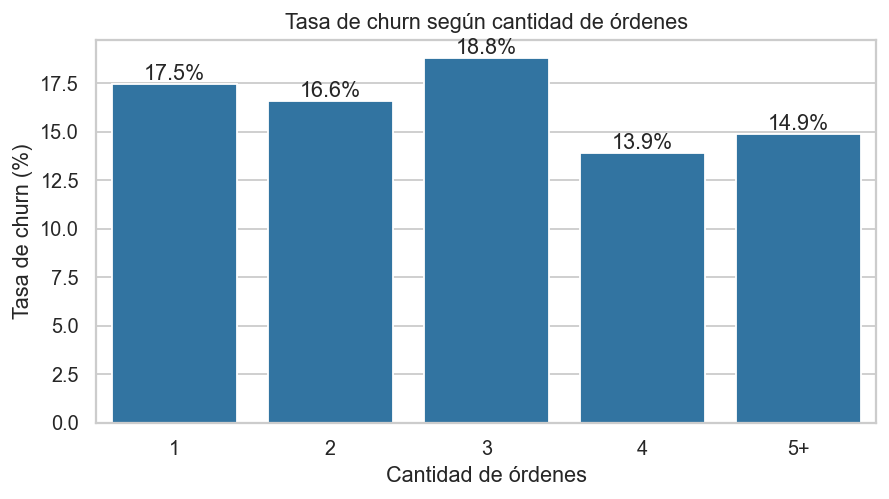

,order_group,clientes,churn_rate_pct
0,1,1529,17.462394
1,2,2032,16.584646
2,3,351,18.803419
3,4,187,13.903743
4,5+,975,14.871795


In [17]:
df_order = df[["OrderCount", "Churn"]].dropna().copy()

df_order["order_group"] = df_order["OrderCount"].apply(
    lambda x: str(int(x)) if x < 5 else "5+"
)

order_churn = (
    df_order
    .groupby("order_group")
    .agg(
        clientes=("Churn", "size"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

order_order = ["1", "2", "3", "4", "5+"]
order_churn["order_group"] = pd.Categorical(
    order_churn["order_group"],
    categories=order_order,
    ordered=True
)
order_churn = order_churn.sort_values("order_group")

order_churn["churn_rate_pct"] = order_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=order_churn,
    x="order_group",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según cantidad de órdenes")
ax.set_xlabel("Cantidad de órdenes")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H4_order_count_churn_rate_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

order_churn[["order_group", "clientes", "churn_rate_pct"]]

In [18]:
h4_result = mann_whitney_test(df, "OrderCount")
h4_result

{'feature': 'OrderCount',
 'test': 'Mann-Whitney U',
 'n_used': 5074,
 'statistic': np.float64(1727878.0),
 'p_value': np.float64(0.15878919660794322),
 'effect_size': np.float64(-0.02926920664402033),
 'mean_churn': np.float64(2.9298454221165278),
 'mean_no_churn': np.float64(3.0633120718166786),
 'median_churn': np.float64(2.0),
 'median_no_churn': np.float64(2.0)}

Las distribuciones de `OrderCount` para clientes activos y clientes que churnearon se superponen fuertemente. El test Mann-Whitney no detecta una diferencia estadísticamente significativa (p = 0,159), el tamaño de efecto es prácticamente nulo y la mediana es igual en ambos grupos. Por eso, `OrderCount` por sí sola no presenta evidencia suficiente como señal de churn.

## H5 - CashbackAmount

**Hipotesis:** Los clientes con menor `CashbackAmount` tienden a churnear mas.

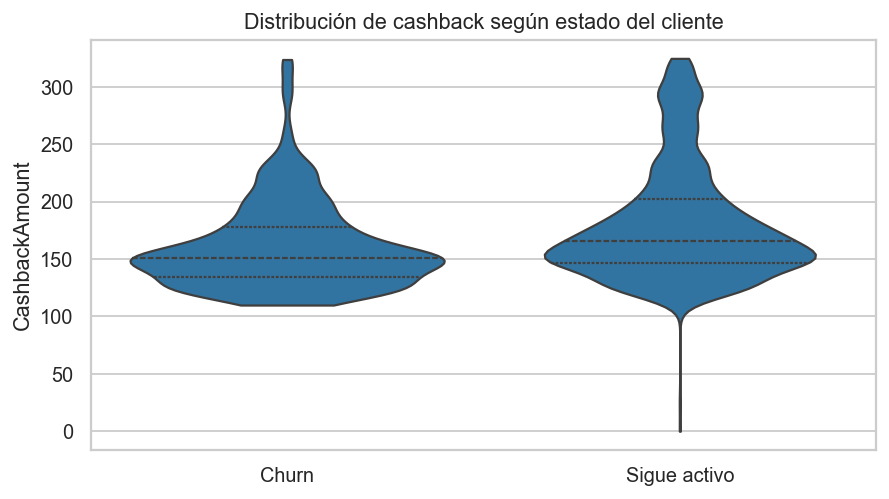

In [19]:
df_cashback = df[["CashbackAmount", "Churn"]].dropna().copy()
df_cashback["estado_cliente"] = df_cashback["Churn"].map({
    0: "Sigue activo",
    1: "Churn"
})

fig, ax = plt.subplots(figsize=(7, 4))

sns.violinplot(
    data=df_cashback,
    x="estado_cliente",
    y="CashbackAmount",
    color="#1f77b4",
    inner="quartile",
    cut=0,
    ax=ax
)

ax.set_title("Distribución de cashback según estado del cliente")
ax.set_xlabel("")
ax.set_ylabel("CashbackAmount")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H5_cashback_violin_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
h5_result = mann_whitney_test(df, "CashbackAmount")
h5_result

{'feature': 'CashbackAmount',
 'test': 'Mann-Whitney U',
 'n_used': 5074,
 'statistic': np.float64(1345355.5),
 'p_value': np.float64(3.996740562389207e-29),
 'effect_size': np.float64(-0.24417232474698403),
 'mean_churn': np.float64(161.77526753864447),
 'mean_no_churn': np.float64(180.78691235530357),
 'median_churn': np.float64(151.0),
 'median_no_churn': np.float64(166.0)}

Los clientes que churnearon muestran un cashback mediano menor que los clientes activos: 151 frente a 166. Esto acompaña la hipótesis de que clientes con menor nivel de beneficios o menor actividad asociada a cashback presentan mayor riesgo de abandono. La asociación es estadísticamente significativa y de magnitud moderada, pero no demuestra que aumentar el cashback reduzca causalmente el churn.

## H6 - DaySinceLastOrder

**Hipotesis:** Los clientes con mas dias desde su ultima orden tienden a churnear mas.

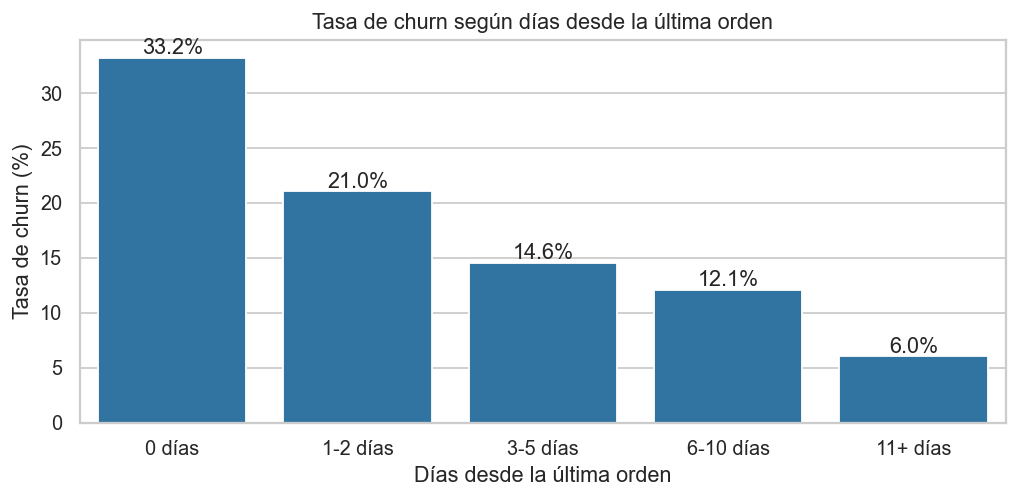

,days_group,clientes,churn_rate_pct
0,0 días,428,33.177570
1,1-2 días,1264,21.044304
2,3-5 días,1682,14.565993
3,6-10 días,1418,12.059238
4,11+ días,282,6.028369


In [21]:
df_days = df[["DaySinceLastOrder", "Churn"]].dropna().copy()

df_days["days_group"] = pd.cut(
    df_days["DaySinceLastOrder"],
    bins=[-1, 0, 2, 5, 10, df_days["DaySinceLastOrder"].max()],
    labels=["0 días", "1-2 días", "3-5 días", "6-10 días", "11+ días"]
)

days_churn = (
    df_days
    .groupby("days_group", observed=True)
    .agg(
        clientes=("Churn", "size"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

days_churn["churn_rate_pct"] = days_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=days_churn,
    x="days_group",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn según días desde la última orden")
ax.set_xlabel("Días desde la última orden")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H6_days_since_last_order_churn_rate_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

days_churn[["days_group", "clientes", "churn_rate_pct"]]

In [22]:
h6_result = mann_whitney_test(df, "DaySinceLastOrder")
h6_result

{'feature': 'DaySinceLastOrder',
 'test': 'Mann-Whitney U',
 'n_used': 5074,
 'statistic': np.float64(1313671.0),
 'p_value': np.float64(8.098875693634212e-34),
 'effect_size': np.float64(-0.26197284065267157),
 'mean_churn': np.float64(3.3079667063020213),
 'mean_no_churn': np.float64(4.727380108669974),
 'median_churn': np.float64(3.0),
 'median_no_churn': np.float64(3.0)}

La hipótesis no se confirma. Las medianas son iguales en ambos grupos (3 días), pero la distribución y las tasas por segmento muestran una relación inversa: el churn es mayor cuando la última orden es más reciente. Esto sugiere que `DaySinceLastOrder` no debe interpretarse de forma directa como inactividad previa al abandono sin revisar cómo y cuándo fue medida la variable.

## H7 - Reclamos y satisfaccion

**Hipotesis:** Los clientes que realizaron reclamos (`Complain = 1`) y tienen baja satisfaccion presentan el mayor riesgo de churn.

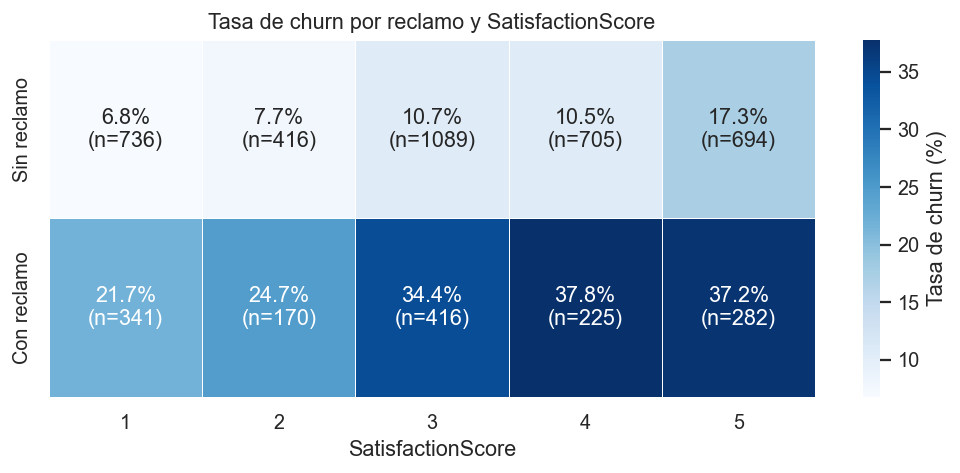

,complain_label,SatisfactionScore,clientes,churn_rate_pct
0,Con reclamo,1,341,21.700880
1,Con reclamo,2,170,24.705882
2,Con reclamo,3,416,34.375000
3,Con reclamo,4,225,37.777778
4,Con reclamo,5,282,37.234043
5,Sin reclamo,1,736,6.793478
6,Sin reclamo,2,416,7.692308
7,Sin reclamo,3,1089,10.651974
8,Sin reclamo,4,705,10.496454
9,Sin reclamo,5,694,17.291066


In [23]:
df_h7 = df[["Complain", "SatisfactionScore", "Churn"]].dropna().copy()

df_h7["complain_label"] = df_h7["Complain"].map({
    0: "Sin reclamo",
    1: "Con reclamo"
})

df_h7["segmento_h7"] = (
    df_h7["complain_label"]
    + " + satisfaction "
    + df_h7["SatisfactionScore"].astype(int).astype(str)
)

h7_churn = (
    df_h7
    .groupby(["complain_label", "SatisfactionScore"])
    .agg(clientes=("Churn", "size"), churn_rate=("Churn", "mean"))
    .reset_index()
)

h7_churn["churn_rate_pct"] = h7_churn["churn_rate"] * 100

h7_heatmap = h7_churn.pivot(
    index="complain_label",
    columns="SatisfactionScore",
    values="churn_rate_pct"
).reindex(["Sin reclamo", "Con reclamo"])

h7_counts = h7_churn.pivot(
    index="complain_label",
    columns="SatisfactionScore",
    values="clientes"
).reindex(["Sin reclamo", "Con reclamo"])

h7_annotations = h7_heatmap.round(1).astype(str) + "%\n(n=" + h7_counts.astype(int).astype(str) + ")"

fig, ax = plt.subplots(figsize=(8, 3.8))

sns.heatmap(
    h7_heatmap,
    annot=h7_annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Tasa de churn (%)"},
    ax=ax
)

ax.set_title("Tasa de churn por reclamo y SatisfactionScore")
ax.set_xlabel("SatisfactionScore")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H7_complain_satisfaction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

h7_churn[["complain_label", "SatisfactionScore", "clientes", "churn_rate_pct"]]

In [24]:
h7_result = chi_square_test(df_h7, "segmento_h7")
h7_result

{'feature': 'segmento_h7',
 'test': 'Chi-square',
 'n_used': 5074,
 'statistic': np.float64(391.5119193079168),
 'p_value': np.float64(8.859712574983999e-79),
 'effect_size': np.float64(0.2777776265227165),
 'dof': 9}

El test chi-cuadrado indica una asociacion estadisticamente significativa entre el segmento combinado `Complain` + `SatisfactionScore` y `Churn` (p-valor < 0.001). La hipotesis se sostiene parcialmente: los clientes con reclamo tienen mayor churn en todos los niveles de satisfaccion, pero el mayor riesgo no aparece necesariamente en la satisfaccion mas baja. Esto refuerza que `Complain` es una senal fuerte, mientras que `SatisfactionScore` requiere una lectura no lineal.

## H8 - Segmento VIP en riesgo

**Hipotesis:** Dentro de los clientes de mayor valor economico, aquellos que realizaron reclamos tienen una tasa de churn desproporcionadamente alta.

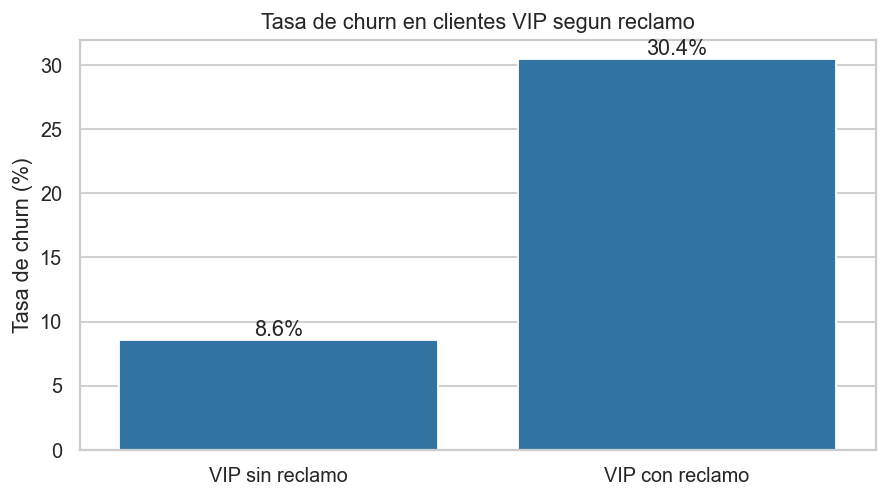

,complain_label,clientes,valor_mediano,churn_rate_pct
1,VIP sin reclamo,931,1197.0,8.592911
0,VIP con reclamo,345,1105.0,30.434783


In [25]:
df_h8 = df[["OrderCount", "CashbackAmount", "Complain", "Churn"]].dropna().copy()
df_h8["ValorCliente"] = df_h8["OrderCount"] * df_h8["CashbackAmount"]
valor_vip_threshold = df_h8["ValorCliente"].quantile(0.75)

df_h8_vip = df_h8[df_h8["ValorCliente"] >= valor_vip_threshold].copy()
df_h8_vip["complain_label"] = df_h8_vip["Complain"].map({
    0: "VIP sin reclamo",
    1: "VIP con reclamo"
})

h8_churn = (
    df_h8_vip
    .groupby("complain_label")
    .agg(clientes=("Churn", "size"), churn_rate=("Churn", "mean"), valor_mediano=("ValorCliente", "median"))
    .reset_index()
)

h8_order = ["VIP sin reclamo", "VIP con reclamo"]
h8_churn["complain_label"] = pd.Categorical(h8_churn["complain_label"], categories=h8_order, ordered=True)
h8_churn = h8_churn.sort_values("complain_label")
h8_churn["churn_rate_pct"] = h8_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=h8_churn,
    x="complain_label",
    y="churn_rate_pct",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Tasa de churn en clientes VIP segun reclamo")
ax.set_xlabel("")
ax.set_ylabel("Tasa de churn (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "H8_vip_complain_churn_rate.png", dpi=150, bbox_inches="tight")
plt.show()

h8_churn[["complain_label", "clientes", "valor_mediano", "churn_rate_pct"]]

In [26]:
h8_result = chi_square_test(df_h8_vip, "Complain")
h8_result

{'feature': 'Complain',
 'test': 'Chi-square',
 'n_used': 1276,
 'statistic': np.float64(95.1190410258948),
 'p_value': np.float64(1.7927404402754798e-22),
 'effect_size': np.float64(0.27302875855548653),
 'dof': 1}

La hipotesis se confirma con claridad. Dentro del cuartil superior de `ValorCliente`, los clientes con reclamo tienen una tasa de churn de 30,4%, frente a 8,6% entre los VIP sin reclamo. El test chi-cuadrado muestra asociacion estadisticamente significativa, y el hallazgo es accionable porque combina riesgo de abandono con impacto economico potencial.